# Day 046 · 完整流水线:数据→分析→图 · 中国版
**End-to-End Pipeline** · 阶段 P2 · Python 量化工具栈

> 前面我们学了一堆零散的本事:拉数据、清洗、算指标、画图、存数据库。但你大概也发现,每次研究都是把这些步骤复制粘贴一遍,改来改去乱成一团。这一节我们把它们串成一条完整的流水线,像工厂的传送带,原料(行情)从一头进去,经过拉取、清洗、分析、画图一道道工序,成品(分析图)从另一头出来。我们把每道工序做成1 块独立的『积木函数』,再用一个总开关串起来;以后想换只股票、换个区间,只改一处配置,整条线自动重跑。我们用格力电器和海尔智家两只票,演示同一条流水线怎么一键处理多只票。

---

### 关于「中国版」

本 notebook 是为**国内学员**优化的版本:
- 数据源用 **akshare**(国内可访问、零 VPN、免注册),取代了视频里的 yfinance
- 标的尽量保持原意:美股 ETF→A 股 ETF / 国际公司→A 股龙头
- 所讲的**概念和方法 100% 一致**,但**具体数字可能与视频里略有差异**(因为是不同时间窗 / 不同标的)
- 一般情况国内 `pip install akshare` 即可,无需 token / VPN

**课件生成日期:** 2026-06-14  ·  **建议学习时长:** 28 分钟

## 🔧 第一步:环境自检 + 自动安装

**第一次拿到这份 notebook,请先运行下面这一格。** 它会:
1. 检查所有必需的 Python 包(含 `akshare`),缺什么自动 `pip install` 装上
2. 注入中文字体到 matplotlib(让图标不出乱码)
3. 跑完看到 `✓ 环境就绪` 就可以继续


In [1]:
# === 环境自检 + 自动安装(运行此单元格即可)===
import importlib, subprocess, sys, os

REQUIRED = ["akshare", "baostock", "matplotlib", "numpy", "numpy_financial", "pandas", "scipy", "sklearn", "statsmodels"]
PIP_NAME = {"sklearn":"scikit-learn","cv2":"opencv-python","PIL":"Pillow","bs4":"beautifulsoup4","yaml":"PyYAML"}

missing = []
for mod in REQUIRED:
    try:
        importlib.import_module(mod)
    except ImportError:
        missing.append(PIP_NAME.get(mod, mod))
if missing:
    print(f"⏳ 缺少 {len(missing)} 个包,自动安装:{missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    print("✓ 安装完成")
else:
    print(f"✓ 所有 {len(REQUIRED)} 个必需库已就绪")

# === 中文字体配置 ===
import matplotlib, matplotlib.pyplot as plt, matplotlib.font_manager as fm
CJK = ["/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
       "C:/Windows/Fonts/msyh.ttc","C:/Windows/Fonts/simhei.ttf",
       "/System/Library/Fonts/PingFang.ttc","/System/Library/Fonts/STHeiti Medium.ttc"]
for p in CJK:
    if os.path.exists(p):
        fm.fontManager.addfont(p)
        print(f"✓ 中文字体已加载:{os.path.basename(p)}")
        break
plt.rcParams["font.sans-serif"] = ["Noto Sans CJK JP","Microsoft YaHei","PingFang SC","SimHei","DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
print("✓ 环境就绪")


✓ 所有 9 个必需库已就绪
✓ 中文字体已加载:NotoSansCJK-Regular.ttc
✓ 环境就绪


## 🔌 第二步:加载国内数据助手

下面这一格是**工具函数**(可以折叠,不需要修改)。它把 `yfinance` 风格的 ticker(如 `600519.SS`)自动路由到对应的 akshare 接口,提供 `get_close(ticker)` 和 `get_close_multi(tickers_dict)` 两个函数。

In [2]:
# === 国内数据源助手(akshare 后端,不需要 VPN)===
# 这一格是工具函数,可以折叠,不需要修改。
# 它把 yfinance 风格的 ticker(如 "600519.SS" / "0700.HK" / "AAPL" / "BTC-USD")
# 自动路由到对应的 akshare 接口,统一返回 yfinance 风格的 Close DataFrame。

import re
from datetime import datetime, timedelta
import pandas as pd
import akshare as ak

_TICKER_MAP = {
    "^GSPC": ("us_index_sina", ".INX"),
    "^DJI":  ("us_index_sina", ".DJI"),
    "^IXIC": ("us_index_sina", ".IXIC"),
    "GC=F":  ("foreign_futures", "GC"),
    "SI=F":  ("foreign_futures", "SI"),
    "CL=F":  ("foreign_futures", "CL"),
    "BTC-USD": ("crypto", "BTC"),
    "ETH-USD": ("crypto", "ETH"),
}

def _retry(fn, *args, _retries=4, _wait=1.5, **kwargs):
    """akshare 上游(东方财富/新浪/Binance)偶有 RemoteDisconnected / Timeout,自动重试 4 次。
    2026-05-11 加:用户跑 cn notebook 拉 002594.SZ 时上游断连 → 整节卡死。
    每次重试间隔 _wait 秒(指数退避 1x → 1.5x → 2.25x)。
    """
    import time as _t
    last_err = None
    wait = _wait
    for i in range(_retries):
        try:
            return fn(*args, **kwargs)
        except Exception as e:
            last_err = e
            name = type(e).__name__
            if i == _retries - 1:
                print(f"  ✗ {getattr(fn,'__name__',str(fn))} 第 {i+1} 次仍失败({name}),放弃")
                raise
            print(f"  ⚠ {getattr(fn,'__name__',str(fn))} 第 {i+1} 次失败({name}),{wait:.1f}s 后重试")
            _t.sleep(wait)
            wait *= 1.5

def _parse_period(period):
    end = datetime.today()
    m = re.match(r"^(\d+)\s*(y|mo|d|w)$", period.lower().strip())
    days = 365 * 3 if not m else int(m.group(1)) * {"y":365,"mo":30,"w":7,"d":1}[m.group(2)]
    return (end - timedelta(days=days+30)).strftime("%Y%m%d"), end.strftime("%Y%m%d")

def _classify(ticker):
    t = ticker.strip()
    if t in _TICKER_MAP: return _TICKER_MAP[t]
    if t.endswith((".SS",".SH",".SZ")):
        code = t.split(".")[0]
        if code.startswith(("51","159","58")) or code in ("510300","510500","510050","511010","513100"):
            return ("a_etf", code)
        if code in ("000300","000016","000905","000852","000001"):
            return ("a_index", code)
        return ("a_stock", code)
    if t.endswith(".HK"):
        return ("hk", t.split(".")[0].zfill(5))
    return ("us", t)

def _norm(df, dc, cc):
    out = df[[dc, cc]].copy()
    out[dc] = pd.to_datetime(out[dc])
    return out.set_index(dc).sort_index()[cc].astype(float).rename("Close")

def get_close(ticker, period="3y"):
    """返回某标的 Close 价格 series。后端 akshare,中国可访问。
    所有 ak.* 调用都过 _retry(4 次,指数退避)— 防东方财富/新浪上游瞬时断连。
    """
    start, end = _parse_period(period)
    kind, sym = _classify(ticker)
    if kind == "a_stock":
        return _norm(_retry(ak.stock_zh_a_hist, symbol=sym, period="daily", start_date=start, end_date=end, adjust="qfq"), "日期", "收盘")
    if kind == "a_etf":
        return _norm(_retry(ak.fund_etf_hist_em, symbol=sym, period="daily", start_date=start, end_date=end, adjust="qfq"), "日期", "收盘")
    if kind == "a_index":
        idx_map = {"000300":"sh000300","000016":"sh000016","000905":"sh000905","000852":"sh000852","000001":"sh000001"}
        s = _norm(_retry(ak.stock_zh_index_daily_em, symbol=idx_map.get(sym, f"sh{sym}")), "date", "close")
        return s.loc[pd.to_datetime(start, format="%Y%m%d"):]
    if kind == "hk":
        return _norm(_retry(ak.stock_hk_hist, symbol=sym, period="daily", start_date=start, end_date=end, adjust="qfq"), "日期", "收盘")
    if kind == "us":
        s = _norm(_retry(ak.stock_us_daily, symbol=sym, adjust="qfq"), "date", "close")
        return s.loc[pd.to_datetime(start, format="%Y%m%d"):]
    if kind == "us_index_sina":
        s = _norm(_retry(ak.index_us_stock_sina, symbol=sym), "date", "close")
        return s.loc[pd.to_datetime(start, format="%Y%m%d"):]
    if kind == "foreign_futures":
        s = _norm(_retry(ak.futures_foreign_hist, symbol=sym), "date", "close")
        return s.loc[pd.to_datetime(start, format="%Y%m%d"):]
    if kind == "crypto":
        import requests as _rq
        def _binance():
            r = _rq.get("https://api.binance.com/api/v3/klines",
                        params={"symbol": f"{sym}USDT", "interval": "1d", "limit": 1000}, timeout=15)
            r.raise_for_status()
            return r.json()
        klines = _retry(_binance)
        df = pd.DataFrame(klines, columns=["open_time","open","high","low","close","volume",
                                            "close_time","qav","trades","tbb","tbq","ignore"])
        df["date"] = pd.to_datetime(df["open_time"], unit="ms")
        df["close"] = df["close"].astype(float)
        s = df.set_index("date").sort_index()["close"].rename("Close")
        return s.loc[pd.to_datetime(start, format="%Y%m%d"):]
    raise ValueError(f"unsupported ticker: {ticker}")

def get_close_multi(tickers, period="3y"):
    """批量取 Close,返回 DataFrame,列名是 tickers dict 的 key(中文名),按交集日期对齐。"""
    series = {name: get_close(t, period=period) for name, t in tickers.items()}
    return pd.concat(series, axis=1).sort_index()

print("✓ cn_data 助手已加载 — 用 get_close(ticker) / get_close_multi(tickers_dict) 拉数据")


✓ cn_data 助手已加载 — 用 get_close(ticker) / get_close_multi(tickers_dict) 拉数据


## 学习目标

- 理解什么是流水线和模块化:把一大坨代码拆成 fetch/clean/analyze/plot 4 块独立积木
- 会把每道工序写成一个职责单一的函数,输入输出清清楚楚
- 会用一个总函数把四道工序串起来,一键处理一只票
- 理解可复用:把要改的参数集中到一个 CONFIG,换票换区间只动一处,整条线重跑
- 知道进阶上专门工具(命令行 click、配置 yaml、日志 loguru、定时 cron)各管什么

## 历史背景:小赵的研究代码越堆越乱,改一个地方崩三个地方

小赵刚学完拉数据、画图,兴致勃勃写了个分析脚本。一开始还好,可慢慢地,他想多看几只票,就把代码复制一份改个代码;想换个时间段,又翻遍整个文件找哪里写了日期;想多算一个指标,结果一改,画图那段莫名其妙报错了。几百行代码搅成一锅粥,改一个地方崩三个地方,他自己都看不懂了。一位做工程的朋友看了直摇头:你这是把所有零件焊死在一起了。正确的做法是像搭积木,拉数据是1 块、清洗是1 块、分析是1 块、画图是1 块,每块管好自己的事,块和块之间用清楚的接口连接。要改哪一步,只动那1 块,别的都不受影响。小赵照着把代码拆成四个函数、参数集中到一处,代码立刻清爽了,换票换区间也不再牵一发动全身。这就是模块化的威力:把复杂拆成简单,把混乱变成有序。



## 核心概念

下面每一节是听完视频后回头细读的内容。

### 1. 流水线与模块化:把大问题拆成几块小积木

做一次完整的量化分析,要经过好几步:拉数据、清洗、分析、画图。新手容易把这些全写成一大坨,结果改哪都怕崩。流水线的思路是把它拆开:每一步做成1 块独立的『积木』(在代码里就是一个函数),每块只管好自己那一摊,输入什么、输出什么清清楚楚。就像工厂的传送带,一道工序接一道工序。拆开之后,哪一步出问题就修哪1 块,想升级哪一步就换哪1 块,别的纹丝不动。这是写出能长期维护的代码的第一课。


### 2. fetch 与 clean:第一、二道工序,拿到数据并洗干净

第1 块积木 fetch 负责拉数据:你给它一个股票代码和时间段,它就去把原始行情取回来,别的不管。第2 块积木 clean 负责清洗:刚拉回来的数据往往是字符串、没排序、可能有缺失,clean 把它转成数字、按日期排好、去掉缺失,交出一张干净规整的表。把『拿数据』和『洗数据』分成两块,好处是:以后换个数据源,只改 fetch;清洗规则要调整,只改 clean,互不打扰。


### 3. analyze 与 plot:第三、四道工序,算出结论并画出来

第3 块积木 analyze 负责分析:接过干净的数据,算出你关心的东西,净值、均线、回撤,再顺手汇总几个关键指标(区间收益、最大回撤)。第4 块积木 plot 负责画图:把分析结果画成一张专业的图。注意它俩的分工,analyze 只算不画、plot 只画不算。这样你想换种算法,只动 analyze;想换种画法,只动 plot。职责单一,是好积木的标志。


### 4. 串起来 + 可复用:一个总开关,换票只改一处

4 块积木有了,用一个总函数 run_one 按顺序把它们串起来:fetch 拿数据 → clean 洗干净 → analyze 算结论 → plot 画图。这就是处理一只票的完整流水线。更妙的是可复用:把所有要改的参数(股票、起止日期、均线窗口)集中放进一个叫 CONFIG 的配置里,主程序对 CONFIG 里的每只票循环跑一遍同一条流水线。想多分析几只票、换个区间?只改 CONFIG 这一处,整条线自动重跑,一行重复代码都不用写。


### 5. 进阶:命令行、配置文件、日志、定时各管什么

等你的流水线要给别人用、要每天自动跑,有几个专门的工具值得认识(知道名字即可,这节先用最朴素的方式实现它们的功能)。click 帮你把脚本变成像专业软件那样的命令行,敲一行命令带参数就能跑;yaml 是一种把配置单独写进一个文件的格式,改参数不用碰代码;loguru 是个好用的日志库,让程序边跑边清楚地告诉你它在干哪一步(我们这节先用 print 代替);cron 是操作系统的定时器,能让你的流水线每天收盘后自动跑一遍。先理解思想,工具是后话。


## 实操:完整流水线 — fetch / clean / analyze / plot 4 块积木 + CONFIG 配置 + run_one 串联(换票只改一处)

本节无外部数据,纯模拟/统计运算,国内国外都能跑。**直接 Run All** 看结果。

**依赖:** `pip install pandas numpy matplotlib akshare statsmodels scipy`

==== 完整流水线:数据→清洗→分析→画图,一键跑完 ====
[流水线] === 开始处理 格力电器 ===
[流水线] fetch:从本地 CSV 读取 sz.000651 -> /mnt/d/huizi_ai_project/ai_course_video/out/notebook/cn/../data/D046_pipeline_sz.000651.csv
[流水线] clean:转数字 + 日期索引 + 去缺失 + 排序
[流水线] analyze:算净值 / 均线 / 回撤
[流水线] plot:画 格力电器 的分析图
[流水线] 格力电器 完成:{'区间收益%': np.float64(48.3), '最大回撤%': np.float64(-24.3), '交易日数': 726}
[流水线] === 开始处理 海尔智家 ===
[流水线] fetch:从本地 CSV 读取 sh.600690 -> /mnt/d/huizi_ai_project/ai_course_video/out/notebook/cn/../data/D046_pipeline_sh.600690.csv
[流水线] clean:转数字 + 日期索引 + 去缺失 + 排序
[流水线] analyze:算净值 / 均线 / 回撤
[流水线] plot:画 海尔智家 的分析图
[流水线] 海尔智家 完成:{'区间收益%': np.float64(4.5), '最大回撤%': np.float64(-32.6), '交易日数': 726}

==== 汇总:两只票跑完同一条流水线的结果对比 ====
      区间收益%  最大回撤%   交易日数
格力电器   48.3  -24.3  726.0
海尔智家    4.5  -32.6  726.0

[done] 同一条流水线处理了 2 只票,每只一张分析图 + 一行汇总,换票只改 CONFIG 即可


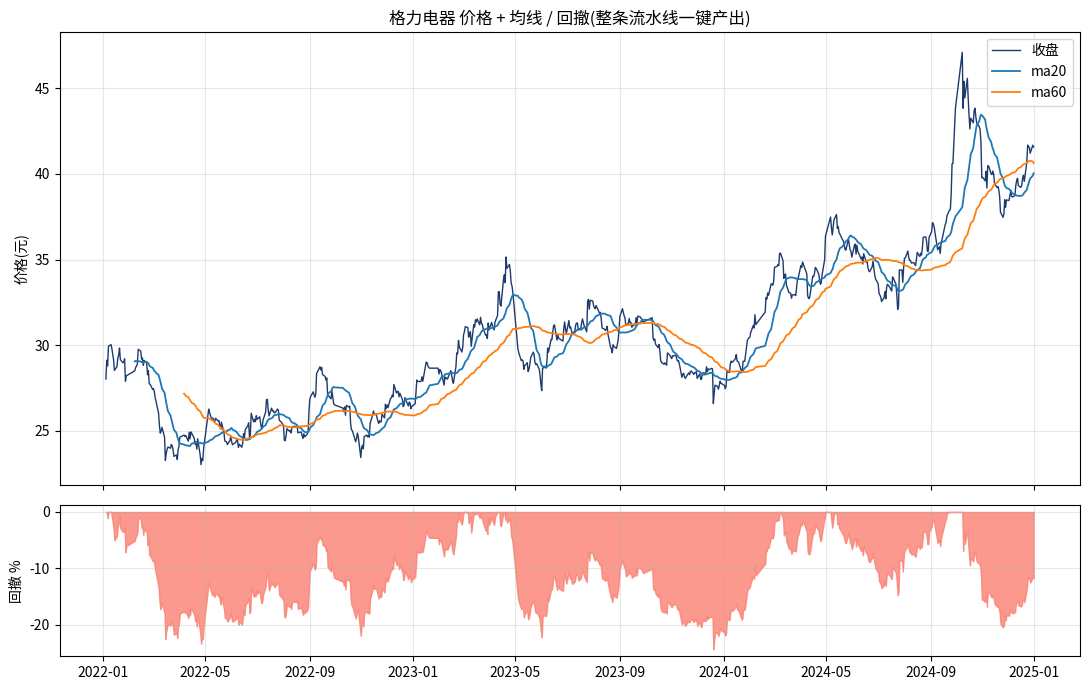

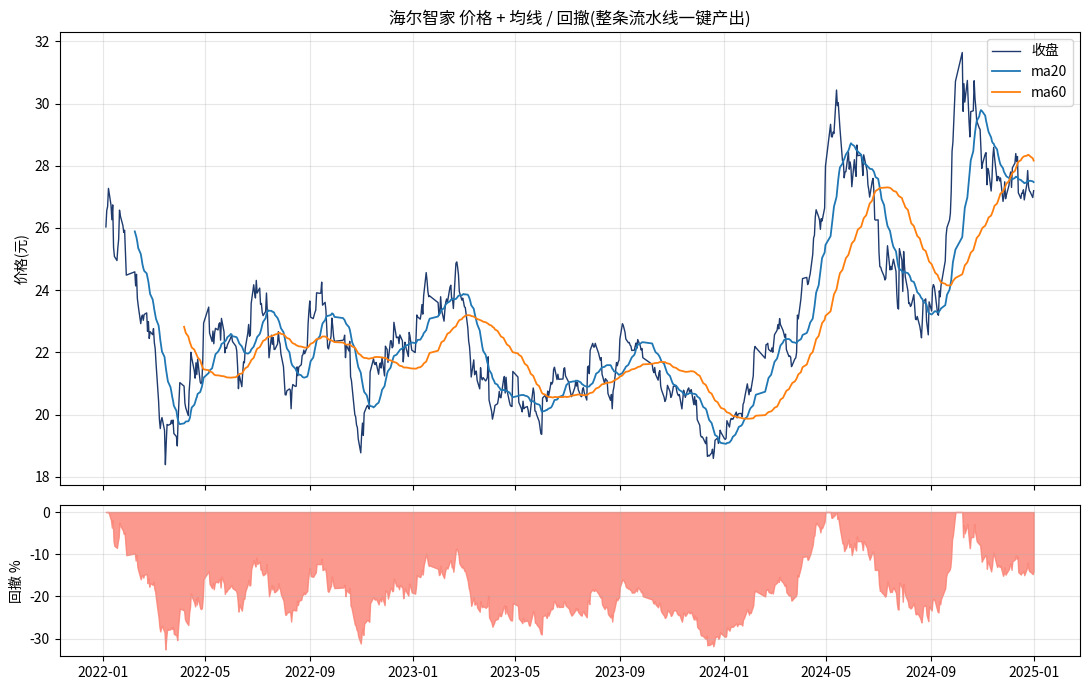

In [3]:
# day_046_pipeline.py — 把零散步骤串成一条可复用的流水线:fetch→clean→analyze→plot
# 像工厂传送带:原料(行情)进去,一道道工序加工,成品(分析图)出来;换只股票整条线重跑
# 数据:baostock 日线(免费、国内零翻墙)。真名上屏:fetch / clean / analyze / plot / CONFIG
import pandas as pd
import matplotlib.pyplot as plt
import baostock as bs

def _data_path(_name):
    # 铁律62:data/ 放在 notebook 文件夹里。仓库根(run_lab)存取 out/notebook/data/;
    # 原版 notebook 在 out/notebook/ 用 data/;中国版在 out/notebook/cn/ 用 ../data/
    from pathlib import Path as _P
    _here = _P.cwd()
    for _b in [_here/'data', _here/'..'/'data', _here/'out'/'notebook'/'data', _here/'..'/'..'/'data', _here/'..'/'..'/'..'/'data']:
        if (_b/_name).exists():
            return str(_b/_name)
    if (_here/'out'/'notebook').exists():
        _t = _here/'out'/'notebook'/'data'
    elif _here.name == 'cn':
        _t = _here/'..'/'data'
    else:
        _t = _here/'data'
    _t.mkdir(parents=True, exist_ok=True)
    return str(_t/_name)

pd.set_option('display.width', 160)
plt.rcParams['axes.unicode_minus'] = False

# ==== 配置集中放一处:想改什么(换票、换区间、换均线)只动这里 ====
CONFIG = {
    'stocks': {'格力电器': 'sz.000651', '海尔智家': 'sh.600690'},
    'start': '2022-01-01',
    'end': '2024-12-31',
    'ma_windows': [20, 60],
}

def log(msg):
    print(f'[流水线] {msg}')

# ---- 第一道工序:fetch 拉数据(CSV 优先,baostock 兜底,拉完自动存 CSV)----
def fetch(code, start, end):
    import os as _os
    _csv = _data_path(f'D046_pipeline_{code}.csv')
    if _os.path.exists(_csv):
        log(f'fetch:从本地 CSV 读取 {code} -> {_csv}')
        return pd.read_csv(_csv)
    log(f'fetch:拉取 {code} 的日线 ...')
    lg = bs.login()
    if lg.error_code != '0':
        raise RuntimeError(f'baostock 登录失败:{lg.error_msg}')
    rs = bs.query_history_k_data_plus(code, 'date,close,volume', start_date=start,
                                      end_date=end, frequency='d', adjustflag='2')
    rows = []
    while rs.error_code == '0' and rs.next():
        rows.append(rs.get_row_data())
    bs.logout()
    raw = pd.DataFrame(rows, columns=['date', 'close', 'volume'])
    raw.to_csv(_csv, index=False)
    log(f'fetch:已存成 CSV -> {_csv}')
    return raw

# ---- 第二道工序:clean 清洗(转类型 + 日期索引 + 去缺失 + 排序)----
def clean(raw):
    log('clean:转数字 + 日期索引 + 去缺失 + 排序')
    df = raw.copy()
    df['date'] = pd.to_datetime(df['date'])
    df['close'] = pd.to_numeric(df['close'])
    df['volume'] = pd.to_numeric(df['volume'])
    return df.dropna().set_index('date').sort_index()

# ---- 第三道工序:analyze 分析(净值 + 均线 + 回撤,顺手算几个指标)----
def analyze(df, ma_windows):
    log('analyze:算净值 / 均线 / 回撤')
    out = df.copy()
    out['nv'] = out['close'] / out['close'].iloc[0]
    for w in ma_windows:
        out[f'ma{w}'] = out['close'].rolling(w).mean()
    out['dd'] = out['nv'] / out['nv'].expanding().max() - 1
    stats = {
        '区间收益%': round((out['nv'].iloc[-1] - 1) * 100, 1),
        '最大回撤%': round(out['dd'].min() * 100, 1),
        '交易日数': len(out),
    }
    return out, stats

# ---- 第四道工序:plot 出图(主图价格+均线,副图回撤)----
def plot(name, out):
    log(f'plot:画 {name} 的分析图')
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                                   gridspec_kw={'height_ratios': [3, 1]})
    ax1.plot(out.index, out['close'], label='收盘', lw=1, color='#1f3b6e')
    for c in [c for c in out.columns if c.startswith('ma')]:
        ax1.plot(out.index, out[c], label=c, lw=1.3)
    ax1.set_title(f'{name} 价格 + 均线 / 回撤(整条流水线一键产出)')
    ax1.set_ylabel('价格(元)'); ax1.legend(); ax1.grid(alpha=0.3)
    ax2.fill_between(out.index, out['dd'] * 100, 0, color='salmon', alpha=0.8)
    ax2.set_ylabel('回撤 %'); ax2.grid(alpha=0.3)
    plt.tight_layout(); plt.savefig(f'{name}.png', dpi=120)

# ---- 把四道工序串起来 = 处理一只票的完整流水线 ----
def run_one(name, code, cfg):
    log(f'=== 开始处理 {name} ===')
    raw = fetch(code, cfg['start'], cfg['end'])
    df = clean(raw)
    out, stats = analyze(df, cfg['ma_windows'])
    plot(name, out)
    log(f'{name} 完成:{stats}')
    return stats

# ==== 主程序:对配置里的每只票跑同一条流水线(可复用)====
print('==== 完整流水线:数据→清洗→分析→画图,一键跑完 ====')
results = {}
for nm, cd in CONFIG['stocks'].items():
    results[nm] = run_one(nm, cd, CONFIG)

print('\n==== 汇总:两只票跑完同一条流水线的结果对比 ====')
summary = pd.DataFrame(results).T
print(summary.to_string())
print('\n[done] 同一条流水线处理了 2 只票,每只一张分析图 + 一行汇总,换票只改 CONFIG 即可')

## 真实市场案例

| 市场 | 标的 | 实战观察 |
| --- | --- | --- |
| A 股 | sz.000651 / sh.600690 | 格力、海尔两只家电龙头跑同一条 fetch→clean→analyze→plot 流水线,各出一张分析图 + 一行汇总 |
| 可复用 |  | 想换成别的票或别的区间,只改 CONFIG 一处,整条流水线自动重跑,不复制粘贴 |
| 每日更新 |  | 把流水线接上定时器,每天收盘后自动拉当天数据、出图,人不用守在电脑前 |
| 团队协作 |  | 模块化后每块职责单一,换数据源只改 fetch、换画法只改 plot,多人协作不打架 |


## 常见坑

### ⚠ 01. 所有代码焊成一大坨,改一处崩一片

把拉数据、清洗、分析、画图全堆在一个长脚本里,变量互相缠绕,改一个地方常常莫名其妙弄坏另一处。拆成职责单一的函数,每块只管自己那摊,改动被隔离,才不会牵一发动全身。

### ⚠ 02. 一个函数既算又画,职责不清

让 analyze 顺手把图也画了,看着省事,其实把『算』和『画』焊死了:以后想换种画法得动分析逻辑,容易出错。坚持 analyze 只算不画、plot 只画不算,职责单一,各自独立。

### ⚠ 03. 参数散落在代码各处,换个值要全文找

股票代码、起止日期、均线窗口如果散写在函数内部,换一次要翻遍全文。集中到一个 CONFIG 配置里,所有可调参数一目了然,改一处即可,这也是后面用 yaml 配置文件的雏形。

### ⚠ 04. 复制粘贴处理多只票,而不是循环

想分析三只票就把整段代码复制3 份改代码,既臃肿又容易漏改。正确做法是把单只票的流程写成一个函数,再对一个股票列表循环调用,这才是『可复用』的意义。

### ⚠ 05. 出错了没有任何提示,黑箱跑半天

流水线跑起来如果一声不吭,中途卡在哪一步你完全不知道。在每道工序打一句日志(这节用 print,进阶用 loguru),让程序边跑边报告进度,出问题能立刻定位到是哪1 块。

## 实战 SOP · 搭一条好流水线的几条规矩

1. 一道工序一个函数,职责单一:fetch 只拿数据、clean 只洗、analyze 只算、plot 只画
2. 所有可调参数集中到一个 CONFIG(进阶用 yaml 文件),换票换区间只改一处
3. 处理多只票用循环调用单只票的流水线函数,绝不复制粘贴整段代码
4. 每道工序打一句日志(print 或 loguru),让程序边跑边报告进度,便于定位问题
5. 先用最朴素的函数 + print 把思想跑通,再按需引入 click/yaml/loguru/cron 等专门工具

> 把这段打印贴在你电脑边。

## 总结 · 你应该带走的

2. 流水线 = 把一次完整分析拆成 fetch→clean→analyze→plot 四道工序,像传送带一道接一道。
3. 模块化 = 每道工序做成1 块职责单一的积木函数,输入输出清楚,改1 块不影响别的。
4. analyze 只算不画、plot 只画不算,职责分清,换算法换画法互不打扰。
5. 用一个总函数 run_one 把4 块串成处理单只票的完整流水线。
6. 可复用 = 参数集中到 CONFIG,对股票列表循环跑同一条线,换票只改一处、不复制粘贴。
7. 进阶工具各管一摊:click 做命令行、yaml 存配置、loguru 记日志、cron 定时跑,先懂思想再上工具。

## 自测题

**Q1.** 为什么要把『拉数据』和『清洗』拆成两个函数,而不是写在一起?各举一个『以后好改』的例子。

**Q2.** analyze 和 plot 的分工是什么?如果让 analyze 顺手把图也画了,以后会带来什么麻烦?

**Q3.** 『可复用』在这节体现在哪里?想把分析的股票从 2 只加到 5 只,你需要改哪里、不需要改哪里?

**Q4.** click、yaml、loguru、cron 这四个进阶工具分别解决什么问题?用大白话各说一句。

把答案写下来,3 天后再回看。

## 下一节预告

**Day 047 · TA-Lib 技术指标** (TA-Lib)

数据能拉能存能成流水线了,下一节我们给分析加点专业武器:用行业标准的技术指标库,一键算出均线、相对强弱、快慢线这些经典指标,不用自己推公式,几行代码批量产出几十个指标,给选股和策略当原料。

## 推荐阅读

- Martin《Clean Code》(2008/Prentice Hall)— 讲『函数职责单一、命名清晰』的经典,模块化思想的源头。
- Reitz & Schlusser《The Hitchhiker's Guide to Python》(2016/O'Reilly)— 讲 Python 项目怎么组织模块和结构,实用。
- click 官方文档(click.palletsprojects.com)— 几分钟学会把脚本变成带参数的命令行工具。
- loguru 官方文档(github.com/Delgan/loguru)— 一行 import 就能用的现代日志库,比 print 优雅。
- Percival《Test-Driven Development with Python》(2017/O'Reilly)— 进阶:怎么给流水线的每块积木写测试,保证重构不出错。